phase 4: model selection

training and comparing random forest and xgboost baselines.

In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# set style
sns.set_theme(style="whitegrid")

In [2]:
# load processed data
print('--- loading processed data ---')
X_train = pd.read_csv('../data/processed/X_train.csv')
X_val = pd.read_csv('../data/processed/X_val.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_val = pd.read_csv('../data/processed/y_val.csv').squeeze()

print(f'train shape: {X_train.shape}')
print(f'val shape: {X_val.shape}')

--- loading processed data ---
train shape: (2516, 23)
val shape: (630, 23)


In [3]:
# train random forest
print('--- random forest baseline ---')
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# evaluate on train
rf_train_preds = rf.predict(X_train)
rf_train_probs = rf.predict_proba(X_train)[:, 1]
rf_train_f1 = f1_score(y_train, rf_train_preds)
rf_train_auc = roc_auc_score(y_train, rf_train_probs)

# evaluate on validation
rf_val_preds = rf.predict(X_val)
rf_val_probs = rf.predict_proba(X_val)[:, 1]
rf_val_f1 = f1_score(y_val, rf_val_preds)
rf_val_auc = roc_auc_score(y_val, rf_val_probs)

print('train metrics:')
print(f'f1 score: {rf_train_f1:.4f} | roc-auc: {rf_train_auc:.4f}')
print('\nval metrics:')
print(f'f1 score: {rf_val_f1:.4f} | roc-auc: {rf_val_auc:.4f}')
print('\ncheck: if train is much higher than val, it is overfitting.')
print('\n--- validation classification report ---')
print(classification_report(y_val, rf_val_preds))

--- random forest baseline ---
train metrics:
f1 score: 1.0000 | roc-auc: 1.0000

val metrics:
f1 score: 0.8133 | roc-auc: 0.7536

check: if train is much higher than val, it is overfitting.

--- validation classification report ---
              precision    recall  f1-score   support

           0       0.67      0.51      0.58       220
           1       0.77      0.87      0.81       410

    accuracy                           0.74       630
   macro avg       0.72      0.69      0.70       630
weighted avg       0.73      0.74      0.73       630



In [4]:
# train xgboost
print('--- xgboost baseline ---')
xgb = XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss')
xgb.fit(X_train, y_train)

# evaluate on train
xgb_train_preds = xgb.predict(X_train)
xgb_train_probs = xgb.predict_proba(X_train)[:, 1]
xgb_train_f1 = f1_score(y_train, xgb_train_preds)
xgb_train_auc = roc_auc_score(y_train, xgb_train_probs)

# evaluate on validation
xgb_val_preds = xgb.predict(X_val)
xgb_val_probs = xgb.predict_proba(X_val)[:, 1]
xgb_val_f1 = f1_score(y_val, xgb_val_preds)
xgb_val_auc = roc_auc_score(y_val, xgb_val_probs)

print('train metrics:')
print(f'f1 score: {xgb_train_f1:.4f} | roc-auc: {xgb_train_auc:.4f}')
print('\nval metrics:')
print(f'f1 score: {xgb_val_f1:.4f} | roc-auc: {xgb_val_auc:.4f}')
print('\ncheck: if train is much higher than val, it is overfitting.')
print('\n--- validation classification report ---')
print(classification_report(y_val, xgb_val_preds))

--- xgboost baseline ---
train metrics:
f1 score: 0.9948 | roc-auc: 0.9999

val metrics:
f1 score: 0.7873 | roc-auc: 0.7200

check: if train is much higher than val, it is overfitting.

--- validation classification report ---
              precision    recall  f1-score   support

           0       0.60      0.44      0.51       220
           1       0.74      0.84      0.79       410

    accuracy                           0.70       630
   macro avg       0.67      0.64      0.65       630
weighted avg       0.69      0.70      0.69       630



--- overfitting / underfitting check ---


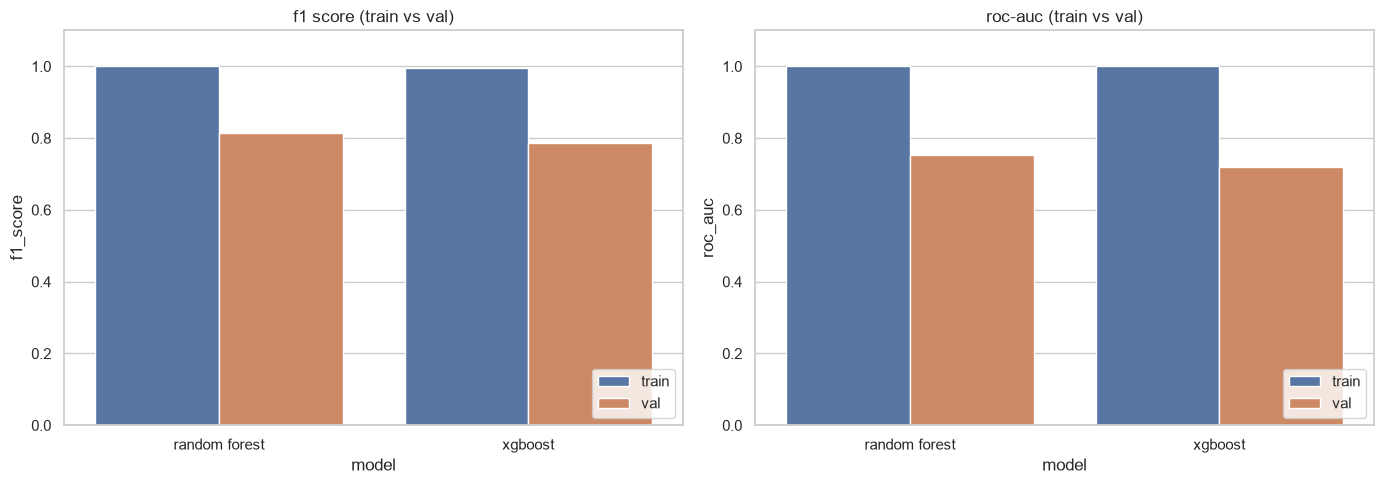

In [5]:
# compare models visually (train vs val)
print('--- overfitting / underfitting check ---')
metrics = pd.DataFrame({
    'model': ['random forest', 'random forest', 'xgboost', 'xgboost'],
    'dataset': ['train', 'val', 'train', 'val'],
    'f1_score': [rf_train_f1, rf_val_f1, xgb_train_f1, xgb_val_f1],
    'roc_auc': [rf_train_auc, rf_val_auc, xgb_train_auc, xgb_val_auc]
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=metrics, x='model', y='f1_score', hue='dataset', ax=axes[0])
axes[0].set_title('f1 score (train vs val)')
axes[0].set_ylim(0, 1.1)
axes[0].legend(loc='lower right')

sns.barplot(data=metrics, x='model', y='roc_auc', hue='dataset', ax=axes[1])
axes[1].set_title('roc-auc (train vs val)')
axes[1].set_ylim(0, 1.1)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

---
**insights from model selection:**
- severe overfitting: both models achieved near 100% on the training set but dropped significantly on validation, proving they are memorizing the small dataset.
- baseline winner: random forest slightly outperformed xgboost right out of the box (0.81 f1 vs 0.79 f1).

**phase 5 tuning strategy:**
- regularization: we must restrict tree depth (max_depth) and increase minimum samples per leaf (min_samples_leaf) to prevent memorization.
- search method: use randomizedsearchcv with 3-fold cross-validation to quickly find the best regularized parameters.
- class balancing: explicitly apply class weights to handle the 65/35 target imbalance.
- final goal: converge the training and validation scores to eliminate the massive overfitting gap.